In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
df = pd.read_csv('bigBasket.csv')

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 62,141
Columns : 5


In [ ]:
raw_df = pd.read_csv("bigBasket.csv")

print(raw_df.shape)
print(raw_df["Created On"].isna().sum())

(62141, 5)
0


In [ ]:
# Identify Excel serial dates
numeric_dates = pd.to_numeric(
    raw_df["Created On"],
    errors="coerce"
)

numeric_mask = numeric_dates.notna()

# Create an empty datetime Series
clean_dates = pd.Series(
    pd.NaT,
    index=raw_df.index,
    dtype="datetime64[ns]"
)

# Convert Excel serial dates
clean_dates.loc[numeric_mask] = pd.to_datetime(
    numeric_dates.loc[numeric_mask],
    unit="D",
    origin="1899-12-30"
)

# Convert string dates: DD/MM/YY HH:MM
clean_dates.loc[~numeric_mask] = pd.to_datetime(
    raw_df.loc[~numeric_mask, "Created On"],
    format="%d/%m/%y %H:%M",
    errors="coerce"
)

# Replace the original column
raw_df["Created On"] = clean_dates

In [ ]:
assert df["Created On"].isna().sum() == 0

In [ ]:
print("Total rows:", len(raw_df))
print("Valid dates:", raw_df["Created On"].notna().sum())
print("Invalid dates:", raw_df["Created On"].isna().sum())

Total rows: 62141
Valid dates: 62141
Invalid dates: 0


In [ ]:
print(raw_df["Created On"].head(10))

0   2014-09-22 22:45:00.287999887
1   2014-09-22 22:45:00.287999887
2   2014-09-22 22:45:00.287999887
3   2014-09-22 22:45:00.287999887
4   2014-09-22 22:45:00.287999887
5   2014-09-22 22:45:00.287999887
6   2014-09-22 22:45:00.287999887
7   2014-09-22 22:45:00.287999887
8   2014-09-22 22:45:00.287999887
9   2014-09-22 22:45:00.287999887
Name: Created On, dtype: datetime64[ns]


In [ ]:
print(raw_df["Created On"].tail(10))

62131   2013-11-16 00:42:59.904000207
62132   2013-11-16 00:42:59.904000207
62133   2013-11-16 00:42:59.904000207
62134   2013-11-16 00:42:59.904000207
62135   2013-11-16 00:42:59.904000207
62136   2013-11-16 00:42:59.904000207
62137   2013-11-16 00:42:59.904000207
62138   2013-11-16 00:42:59.904000207
62139   2013-11-16 00:42:59.904000207
62140   2013-11-16 00:42:59.904000207
Name: Created On, dtype: datetime64[ns]


In [ ]:
print("Earliest date:", raw_df["Created On"].min())
print("Latest date  :", raw_df["Created On"].max())

Earliest date: 2011-03-12 10:18:00
Latest date  : 2014-12-09 21:35:00


In [ ]:
df = raw_df.copy()

In [ ]:
print(df.shape)
print(df.isna().sum())

(62141, 5)
Member         0
Order          0
SKU            0
Created On     0
Description    0
dtype: int64


In [ ]:
df.head(10)

,Member,Order,SKU,Created On,Description
0,M09736,6468572,34993740,2014-09-22 22:45:00.287999887,Other Sauces
1,M09736,6468572,15669800,2014-09-22 22:45:00.287999887,Cashews
2,M09736,6468572,34989501,2014-09-22 22:45:00.287999887,Other Dals
3,M09736,6468572,7572303,2014-09-22 22:45:00.287999887,Namkeen
4,M09736,6468572,15669856,2014-09-22 22:45:00.287999887,Sugar
5,M09736,6468572,15668478,2014-09-22 22:45:00.287999887,Banana
6,M09736,6468572,21409124,2014-09-22 22:45:00.287999887,Sugar Cubes
7,M09736,6468572,34938526,2014-09-22 22:45:00.287999887,Other Sweets
8,M09736,6468572,15669778,2014-09-22 22:45:00.287999887,Other Dals
9,M09736,6468572,34989440,2014-09-22 22:45:00.287999887,Other Rice Products


In [ ]:
df.tail(10)

,Member,Order,SKU,Created On,Description
62131,M64379,8381435,15668462,2013-11-16 00:42:59.904000207,Gourd & Cucumber
62132,M64379,8381435,15669789,2013-11-16 00:42:59.904000207,Boiled Rice
62133,M64379,8381435,15668468,2013-11-16 00:42:59.904000207,Beans
62134,M64379,8381435,7629391,2013-11-16 00:42:59.904000207,"Glucose, Marie & Milk Biscuits"
62135,M64379,8381435,15668478,2013-11-16 00:42:59.904000207,Banana
62136,M64379,8381435,15670260,2013-11-16 00:42:59.904000207,Organic F&V
62137,M64379,8381435,15668597,2013-11-16 00:42:59.904000207,Exotic Vegetables
62138,M64379,8381435,7570555,2013-11-16 00:42:59.904000207,Shoe Polish
62139,M64379,8381435,7587490,2013-11-16 00:42:59.904000207,Organic Dals & Pulses
62140,M64379,8381435,15669830,2013-11-16 00:42:59.904000207,Other Rice Products


In [ ]:
df.sample(10, random_state=42)

,Member,Order,SKU,Created On,Description
11272,M16218,7873660,15668453,2014-10-06 19:10:00.000000000,Brinjals
47772,M51278,6621002,15668416,2014-05-08 10:47:00.000000000,Banana
48525,M52629,7579630,7569799,2013-05-28 11:55:00.191999714,Namkeen
22893,M33558,7833785,15668467,2012-01-27 12:17:00.384000311,Beans
17115,M32409,6572650,34986129,2014-08-30 10:07:59.808000034,Whole Spices
47872,M51278,7398611,15668416,2013-07-10 11:50:00.000000000,Banana
253,M09736,7948600,21409124,2014-05-23 23:26:59.711999732,Sugar Cubes
38444,M43831,8358819,34986125,2013-02-11 00:21:00.000000000,Whole Spices
14933,M31908,6549868,34989502,2014-10-09 01:37:00.000000000,Other Dals
37753,M43831,6532026,7570758,2014-05-09 17:21:00.000000000,Toilet Cleaners


In [ ]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62141 entries, 0 to 62140
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Member       62141 non-null  object        
 1   Order        62141 non-null  int64         
 2   SKU          62141 non-null  int64         
 3   Created On   62141 non-null  datetime64[ns]
 4   Description  62141 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.4+ MB


,0
Member,object
Order,int64
SKU,int64
Created On,datetime64[ns]
Description,object


In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Member,62141,106,M38622,1438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order,"62,141.00",NaN,NaN,NaN,"7,642,313.18","6,422,558.00","7,457,967.00","7,725,501.00","8,006,749.00","8,388,492.00","513,111.67"
SKU,"62,141.00",NaN,NaN,NaN,"17,743,227.96","6,884,195.00","15,668,381.00","15,668,520.00","15,669,867.00","93,319,504.00","14,424,765.99"
Created On,62141,NaN,NaN,NaN,2013-09-20 09:01:14.278562304,2011-03-12 10:18:00,2013-03-21 13:48:59.615999744,2013-10-05 07:09:00,2014-04-17 17:01:59.808000,2014-12-09 21:35:00,NaN
Description,62141,216,Other Vegetables,4606,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique():,}")
    print(df[col].dropna().unique()[:10])


Column: Member
Unique values: 106
['M09736' 'M39021' 'M47229' 'M76390' 'M77779' 'M78365' 'M78720' 'M82651'
 'M84827' 'M86304']

Column: Order
Unique values: 8,387
[6468572 6486475 6504964 6529569 6549521 6562518 6596905 6612806 6624000
 6638454]

Column: SKU
Unique values: 1,732
[34993740 15669800 34989501  7572303 15669856 15668478 21409124 34938526
 15669778 34989440]

Column: Created On
Unique values: 8,352
<DatetimeArray>
['2014-09-22 22:45:00.287999887', '2014-09-28 14:06:00.000000129',
 '2014-09-14 23:06:00.000000129',           '2014-04-09 22:56:00',
           '2014-09-09 23:10:00', '2014-08-26 22:54:59.903999827',
 '2014-08-17 22:50:00.096000172', '2014-08-22 19:21:59.616000190',
           '2014-06-08 08:14:00',           '2014-10-08 09:40:00']
Length: 10, dtype: datetime64[ns]

Column: Description
Unique values: 216
['Other Sauces' 'Cashews' 'Other Dals' 'Namkeen' 'Sugar' 'Banana'
 'Sugar Cubes' 'Other Sweets' 'Other Rice Products' 'Utensil Scrub Pads']


In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing.sort_values("missing_count", ascending=False)

,missing_count,missing_percentage
Member,0,0.00
Order,0,0.00
SKU,0,0.00
Created On,0,0.00
Description,0,0.00


In [ ]:
exact_duplicates = df.duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates:,}")
transaction_duplicates = df.duplicated(
    subset=["Member", "Order", "SKU"]
).sum()

print(
    f"Duplicate Member + Order + SKU records: "
    f"{transaction_duplicates:,}"
)

Exact duplicate rows: 0
Duplicate Member + Order + SKU records: 0


In [ ]:
entity_summary = pd.DataFrame({
    "Entity": [
        "Customers",
        "Orders",
        "SKUs",
        "Descriptions"
    ],
    "Unique_Count": [
        df["Member"].nunique(),
        df["Order"].nunique(),
        df["SKU"].nunique(),
        df["Description"].nunique()
    ]
})

entity_summary

,Entity,Unique_Count
0,Customers,106
1,Orders,8387
2,SKUs,1732
3,Descriptions,216


In [ ]:
df["Year"] = df["Created On"].dt.year
df["Month"] = df["Created On"].dt.month
df["YearMonth"] = df["Created On"].dt.to_period("M")
yearly_orders = (
    df.groupby("Year")["Order"]
    .nunique()
    .reset_index(name="Orders")
)
yearly_orders

,Year,Orders
0,2011,20
1,2012,1291
2,2013,3802
3,2014,3274


In [ ]:
monthly_orders = (
    df.groupby("YearMonth")["Order"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders

,YearMonth,Orders
0,2011-03,3
1,2011-04,1
2,2011-07,1
3,2011-08,2
4,2011-12,13
5,2012-01,55
6,2012-02,60
7,2012-03,68
8,2012-04,57
9,2012-05,78


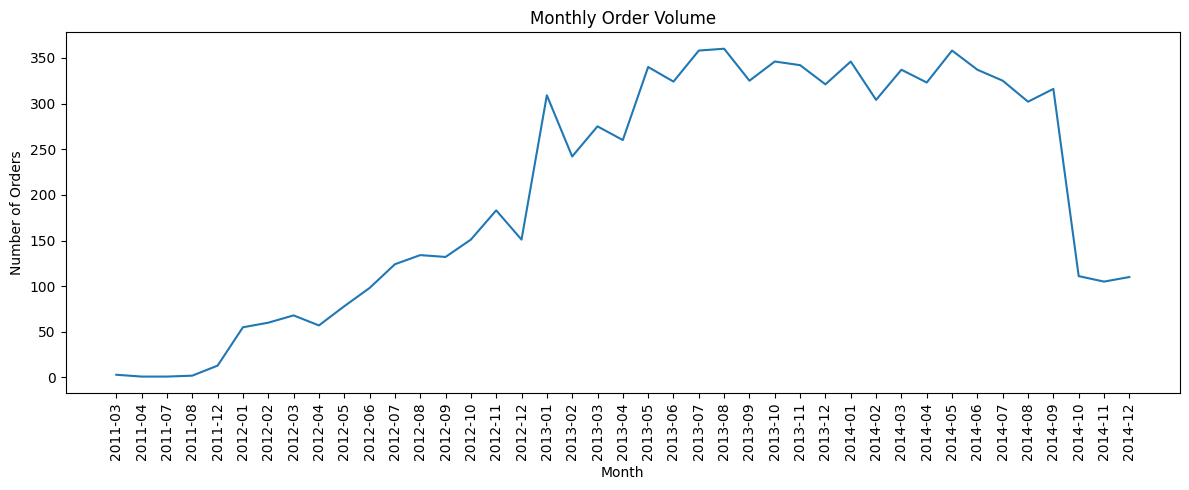

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["YearMonth"].astype(str),
    monthly_orders["Orders"]
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
orders_per_customer = (
    df.groupby("Member")["Order"]
    .nunique()
)
orders_per_customer.describe()

,Order
count,106.00
mean,79.12
std,32.25
min,24.00
25%,55.25
50%,75.00
75%,93.50
max,203.00


In [ ]:
orders_per_customer.sort_values(ascending=False).head(10)

,Order
Member,
M36432,203
M33064,178
M33491,156
M38622,139
M42182,139
M31966,137
M42513,133
M04158,132
M45470,126


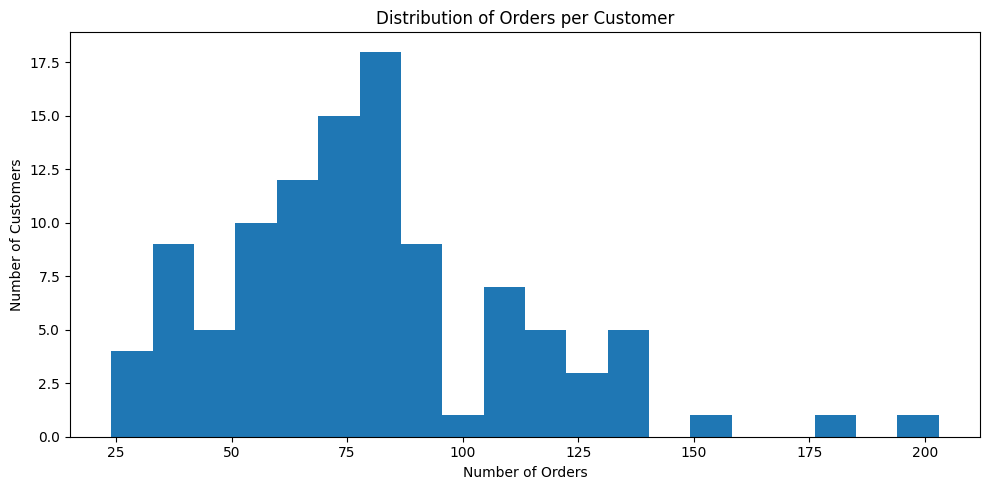

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders_per_customer,
    bins=20
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
basket_size = (
    df.groupby("Order")["SKU"]
    .nunique()
    .rename("basket_size")
)

basket_size.describe()

,basket_size
count,"8,387.00"
mean,7.41
std,4.96
min,1.00
25%,4.00
50%,7.00
75%,10.00
max,42.00


In [ ]:
print("Average basket size:", basket_size.mean())
print("Median basket size :", basket_size.median())
print("Maximum basket size:", basket_size.max())

Average basket size: 7.409204721592942
Median basket size : 7.0
Maximum basket size: 42


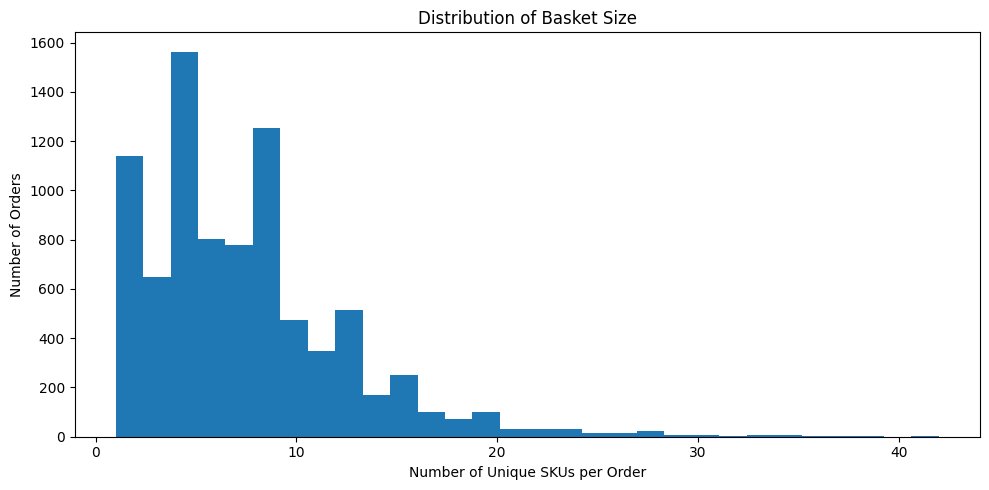

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    basket_size,
    bins=30
)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Unique SKUs per Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [ ]:
sku_frequency = (
    df.groupby(["SKU", "Description"])
      .size()
      .reset_index(name="purchase_count")
      .sort_values("purchase_count", ascending=False)
)

sku_frequency.head(20)

,SKU,Description,purchase_count
683,15668381,Other Vegetables,1702
737,15668688,Root Vegetables,1540
698,15668460,Gourd & Cucumber,1439
681,15668379,Other Vegetables,1415
716,15668478,Banana,1252
706,15668468,Beans,1137
680,15668378,Other Vegetables,1003
705,15668467,Beans,963
686,15668416,Banana,936
703,15668465,Root Vegetables,923


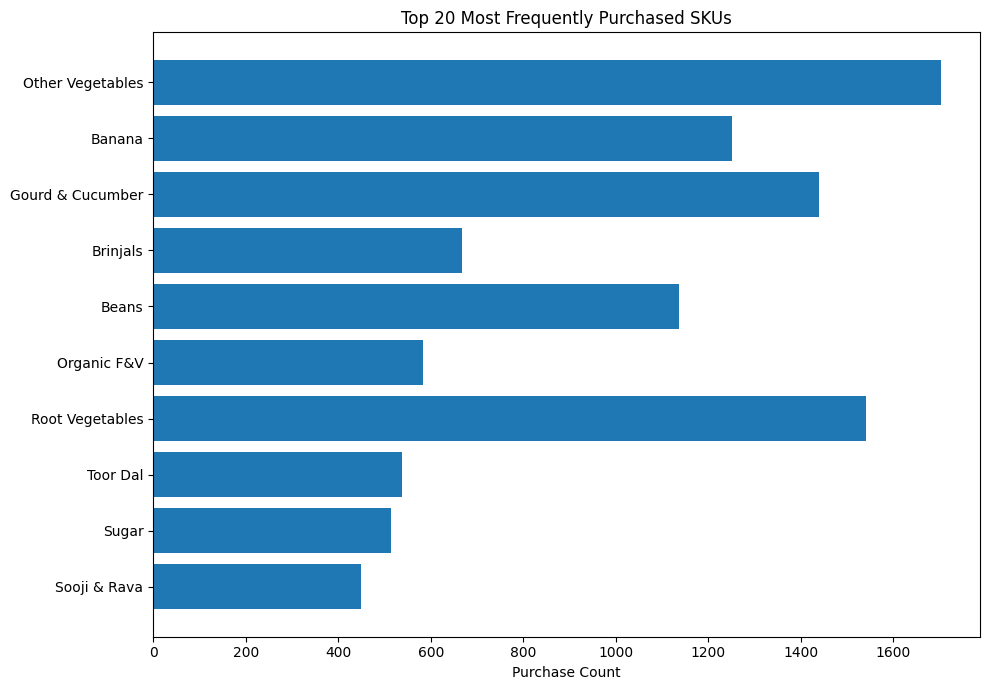

In [ ]:
top_20 = sku_frequency.head(20).sort_values("purchase_count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_20["Description"],
    top_20["purchase_count"]
)

plt.title("Top 20 Most Frequently Purchased SKUs")
plt.xlabel("Purchase Count")

plt.tight_layout()
plt.show()

In [ ]:
sku_description = (
    df.groupby("Description")["SKU"]
      .nunique()
      .sort_values(ascending=False)
)

sku_description.head(20)

,SKU
Description,
Namkeen,63
Whole Spices,46
Organic F&V,44
Health Drinks,41
Ice Creams & Desserts,33
Other Dals,32
Corn Snacks,30
Liquid Soaps & Bars,27
Organic Masalas & Spices,27


In [ ]:
print(
    "Descriptions associated with multiple SKUs:",
    (sku_description > 1).sum()
)
sku_description.describe()

Descriptions associated with multiple SKUs: 175


,SKU
count,216.00
mean,8.02
std,8.95
min,1.00
25%,2.00
50%,5.00
75%,11.00
max,63.00


In [ ]:
customer_product = (
    df.groupby(["Member", "SKU"])
      .size()
      .reset_index(name="purchase_count")
)
customer_product["is_repeat"] = (
    customer_product["purchase_count"] > 1
)
customer_product["is_repeat"].value_counts()


,count
is_repeat,
True,8328
False,7157


In [ ]:
repeat_percentage = (
    customer_product["is_repeat"].mean() * 100
)

print(
    f"Customer-SKU relationships involving repeat purchases: "
    f"{repeat_percentage:.2f}%"
)

Customer-SKU relationships involving repeat purchases: 53.78%


In [ ]:
customer_product["purchase_count"].describe()


,purchase_count
count,"15,485.00"
mean,4.01
std,6.24
min,1.00
25%,1.00
50%,2.00
75%,4.00
max,75.00


In [ ]:
customer_product["purchase_count"].value_counts().sort_index().head(20)

,count
purchase_count,
1,7157
2,2535
3,1346
4,897
5,611
6,443
7,353
8,300
9,271


In [ ]:
df = df.sort_values(
    ["Member", "SKU", "Created On"]
).copy()

df["previous_purchase_date"] = (
    df.groupby(["Member", "SKU"])["Created On"]
      .shift(1)
)

df["days_since_previous_purchase"] = (
    df["Created On"] - df["previous_purchase_date"]
).dt.total_seconds() / (24 * 60 * 60)

reorder_intervals = (
    df["days_since_previous_purchase"]
    .dropna()
)

print("Mean reorder interval:",
      reorder_intervals.mean())

print("Median reorder interval:",
      reorder_intervals.median())

print("Minimum reorder interval:",
      reorder_intervals.min())

print("Maximum reorder interval:",
      reorder_intervals.max())

Mean reorder interval: 71.05056870932405
Median reorder interval: 33.826040555555764
Minimum reorder interval: 0.0027699999990972225
Maximum reorder interval: 1033.6715277777778


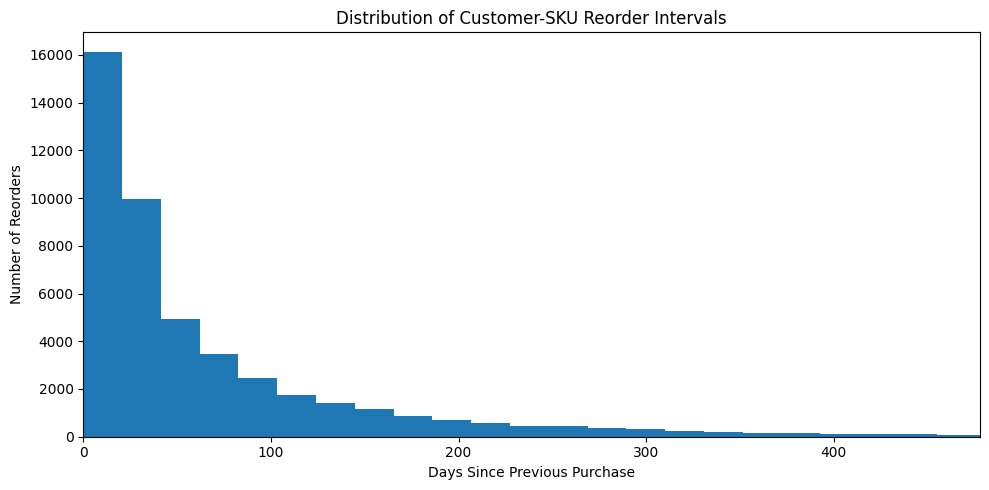

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    reorder_intervals,
    bins=50
)

plt.title("Distribution of Customer-SKU Reorder Intervals")
plt.xlabel("Days Since Previous Purchase")
plt.ylabel("Number of Reorders")

plt.xlim(0, reorder_intervals.quantile(0.99))

plt.tight_layout()
plt.show()

In [ ]:
orders = (
    df.groupby(["Member", "Order"], as_index=False)
      .agg(
          order_date=("Created On", "min"),
          basket_size=("SKU", "nunique")
      )
      .sort_values(["Member", "order_date"])
)

orders["order_number"] = (
    orders.groupby("Member")
          .cumcount() + 1
)

In [ ]:
customer_history = (
    orders.groupby("Member")
          .agg(
              total_orders=("Order", "nunique"),
              first_order=("order_date", "min"),
              last_order=("order_date", "max")
          )
          .reset_index()
)

customer_history["history_days"] = (
    customer_history["last_order"] -
    customer_history["first_order"]
).dt.days

customer_history.describe()

,total_orders,first_order,last_order,history_days
count,106.00,106,106,106.00
mean,79.12,2012-05-14 08:10:35.649509376,2014-11-10 12:44:52.643320832,909.71
min,24.00,2011-03-12 10:18:00,2013-08-27 18:04:59.808000285,510.00
25%,55.25,2012-01-12 09:13:45,2014-11-05 21:15:15,700.25
50%,75.00,2012-03-12 21:15:30,2014-12-03 11:24:30,957.50
75%,93.50,2012-12-29 01:19:59.736000,2014-12-07 08:20:45,"1,031.00"
max,203.00,2013-07-12 11:13:00,2014-12-09 21:35:00,"1,334.00"
std,32.25,NaN,NaN,180.26


In [ ]:
customer_history.sort_values(
    "total_orders",
    ascending=False
).head(10)

,Member,total_orders,first_order,last_order,history_days
34,M36432,203,2012-03-25 08:39:00.287999758,2014-12-07 02:41:00,986
22,M33064,178,2012-01-19 11:37:59.808000034,2014-12-07 11:19:00,1052
24,M33491,156,2012-01-10 10:48:00.000000000,2014-12-02 19:30:00,1057
39,M38622,139,2012-01-10 09:54:00.000000000,2014-12-08 23:29:00,1063
45,M42182,139,2012-02-08 09:10:00.000000000,2014-12-06 06:27:00,1031
16,M31966,137,2011-03-12 10:18:00.000000000,2014-11-04 17:36:00,1333
46,M42513,133,2012-01-12 09:09:00.000000000,2014-12-04 09:21:00,1057
0,M04158,132,2012-04-12 20:09:00.000000000,2014-12-04 19:54:00,965
53,M45470,126,2012-01-12 09:28:00.000000000,2014-12-02 10:36:00,1055
59,M48101,124,2012-01-10 23:30:00.000000000,2014-11-09 13:40:00,1033


In [ ]:
eligible_customers = (
    customer_history["total_orders"] >= 2
).sum()

total_customers = len(customer_history)

print(
    f"Customers with at least 2 orders: "
    f"{eligible_customers}/{total_customers}"
)

Customers with at least 2 orders: 106/106


In [ ]:
original_columns = [
    "Member",
    "Order",
    "SKU",
    "Created On",
    "Description"
]

quality_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Original Columns",
        "Unique Customers",
        "Unique Orders",
        "Unique SKUs",
        "Unique Descriptions",
        "Missing Values",
        "Exact Duplicate Rows",
        "Duplicate Member-Order-SKU",
        "Earliest Date",
        "Latest Date",
        "Average Basket Size",
        "Median Basket Size",
        "Average Orders per Customer",
        "Median Orders per Customer",
        "Customer-SKU Repeat Rate",
        "Average Customer-SKU Reorder Interval",
        "Median Customer-SKU Reorder Interval"
    ],
    "Value": [
        len(df),
        len(original_columns),
        df["Member"].nunique(),
        df["Order"].nunique(),
        df["SKU"].nunique(),
        df["Description"].nunique(),
        df[original_columns].isna().sum().sum(),
        df[original_columns].duplicated().sum(),
        df[original_columns].duplicated(
            subset=["Member", "Order", "SKU"]
        ).sum(),
        df["Created On"].min(),
        df["Created On"].max(),
        basket_size.mean(),
        basket_size.median(),
        orders_per_customer.mean(),
        orders_per_customer.median(),
        repeat_percentage,
        reorder_intervals.mean(),
        reorder_intervals.median()
    ]
})

quality_report

,Metric,Value
0,Rows,62141
1,Original Columns,5
2,Unique Customers,106
3,Unique Orders,8387
4,Unique SKUs,1732
5,Unique Descriptions,216
6,Missing Values,0
7,Exact Duplicate Rows,0
8,Duplicate Member-Order-SKU,0
9,Earliest Date,2011-03-12 10:18:00


In [ ]:
df.to_csv('modified_bigBasket.csv', index=False)